In [81]:
import torch
import math

# pick a pair from a vector

x = torch.tensor([0.9, -0.3, 0.2, 0.6])

pair = x[0:2]
pair

tensor([ 0.9000, -0.3000])

In [82]:
# rotation matrix
# R(a) = [cos a -sin a]
#        [sin a  cos a]

# position
m = 2           # TOKEN is at position 2
pair_idx = 0    # first pair
head_dim = 4
base = 10000

theta = base ** (-2 * pair_idx / head_dim)
alpha = m * theta

alpha

2.0

In [83]:
R = torch.tensor([
    [math.cos(alpha), -math.sin(alpha)],
    [math.sin(alpha),  math.cos(alpha)]
])
R

tensor([[-0.4161, -0.9093],
        [ 0.9093, -0.4161]])

In [84]:
rotated = R @ pair
rotated

tensor([-0.1017,  0.9432])

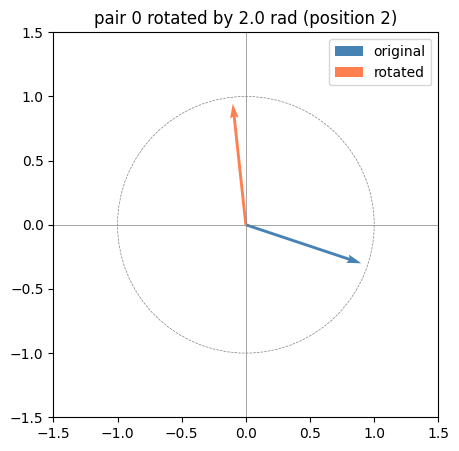

In [85]:
import matplotlib.pyplot as plt

origin = [0, 0]

plt.figure(figsize=(5, 5))
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

plt.quiver(*origin, pair[0], pair[1], angles='xy', scale_units='xy', scale=1, color='steelblue', label='original')
plt.quiver(*origin, rotated[0], rotated[1], angles='xy', scale_units='xy', scale=1, color='coral', label='rotated')

circle = plt.Circle((0, 0), 1, fill=False, linestyle='dashed', linewidth=0.5, color='gray')
plt.gca().add_patch(circle)

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.gca().set_aspect('equal')
plt.legend()
plt.title('pair 0 rotated by 2.0 rad (position 2)')
plt.show()

In [86]:
# full computation

torch.manual_seed(0)

seq_len = 4
head_dim = 8
base = 10000

q = torch.randn(seq_len, head_dim)
k = torch.randn(seq_len, head_dim)

positions = torch.arange(seq_len)

In [87]:
num_pairs = head_dim // 2

for pair_idx in range(num_pairs):
    theta = base ** (-2 * pair_idx / head_dim)
    print(f"pair {pair_idx}: theta = {theta:.6f}")

pair 0: theta = 1.000000
pair 1: theta = 0.100000
pair 2: theta = 0.010000
pair 3: theta = 0.001000


In [88]:
q_rotated = torch.zeros_like(q)
k_rotated = torch.zeros_like(k)

for pair_idx in range(num_pairs):
    theta = base ** (-2 * pair_idx / head_dim)
    for tok_idx in range(seq_len):
        m = positions[tok_idx].item()
        alpha = m * theta

        R = torch.tensor([
            [math.cos(alpha), -math.sin(alpha)],
            [math.sin(alpha), math.cos(alpha)]
        ])

        q_pair = q[tok_idx, 2*pair_idx : 2*pair_idx+2]
        q_rotated[tok_idx, 2*pair_idx : 2*pair_idx+2] = R @ q_pair

q_rotated

tensor([[-1.1258, -1.1524, -0.2506, -0.4339,  0.8487,  0.6920, -0.3160, -2.1152],
        [ 1.2372, -0.4114,  0.3175,  0.3415,  0.1075,  1.2388,  1.1170, -0.2462],
        [ 2.1050, -0.5242,  0.3977,  0.8903,  0.6298, -1.5428, -0.3451,  1.8523],
        [-0.6601,  0.6855, -0.2199,  0.1240,  1.3412,  1.6273,  0.9488, -0.8408]])

In [89]:
for pair_idx in range(num_pairs):
    theta = base ** (-2 * pair_idx / head_dim)
    for tok_idx in range(seq_len):
        m = positions[tok_idx].item()
        alpha = m * theta

        R = torch.tensor([
            [math.cos(alpha), -math.sin(alpha)],
            [math.sin(alpha), math.cos(alpha)]
        ])

        k_pair = k[tok_idx, 2*pair_idx:2*pair_idx+2]
        k_rotated[tok_idx, 2*pair_idx:2*pair_idx+2] = R @ k_pair
k_rotated

tensor([[-0.6136,  0.0316, -0.4927,  0.2484,  0.4397,  0.1124,  0.6408,  0.4412],
        [-0.7221,  0.3421, -0.2935,  0.0233,  0.4998,  2.3073, -1.4673, -1.5882],
        [-0.5136, -0.9753,  0.9990,  0.3840, -0.2225, -0.3963,  0.5441, -0.3941],
        [ 0.3368, -0.7995,  0.4452,  3.7077, -1.4935, -1.2795,  1.8214, -0.5461]])

In [90]:
scores = (q_rotated @ k_rotated.T) / math.sqrt(head_dim)
print(scores)

tensor([[-0.0052,  2.2366,  0.5246, -0.9728],
        [-0.0177,  0.1926,  0.1429,  0.9110],
        [-0.2063, -2.6431, -0.0980,  1.4140],
        [ 0.5570,  1.8196, -0.2111, -0.8154]])


In [91]:
print(scores[1, 3])

tensor(0.9110)


In [92]:
q_raw = q[1:2]

k_relative = torch.zeros(1, head_dim)

for pair_idx in range(num_pairs):
    theta = base ** (-2 * pair_idx / head_dim)
    alpha = 2 * theta

    R = torch.tensor([
        [math.cos(alpha), -math.sin(alpha)],
        [math.sin(alpha), math.cos(alpha)]
    ])

    k_pair = k[3, 2*pair_idx:2*pair_idx+2]
    k_relative[0, 2*pair_idx:2*pair_idx+2] = R @ k_pair

score_relative = (q_raw @ k_relative.T) / math.sqrt(head_dim)
print(score_relative)

tensor([[0.9110]])


In [93]:
weights = torch.softmax(scores, dim=-1)
print(weights)

tensor([[0.0801, 0.7535, 0.1360, 0.0304],
        [0.1684, 0.2078, 0.1977, 0.4262],
        [0.1378, 0.0121, 0.1536, 0.6966],
        [0.1904, 0.6730, 0.0883, 0.0483]])


In [94]:
# actual implementation
pair_indices = torch.arange(num_pairs)
thetas = base ** (-2 * pair_indices / head_dim)
print(thetas)

tensor([1.0000, 0.1000, 0.0100, 0.0010])


In [95]:
angles = positions.unsqueeze(1) * thetas.unsqueeze(0)
print(angles.shape)
print(angles)

torch.Size([4, 4])
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+00, 1.0000e-01, 1.0000e-02, 1.0000e-03],
        [2.0000e+00, 2.0000e-01, 2.0000e-02, 2.0000e-03],
        [3.0000e+00, 3.0000e-01, 3.0000e-02, 3.0000e-03]])


In [96]:
cos_table = torch.cos(angles).repeat_interleave(2, dim=1)
sin_table = torch.sin(angles).repeat_interleave(2, dim=1)
print(cos_table.shape)
print(cos_table)

torch.Size([4, 8])
tensor([[ 1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000],
        [ 0.5403,  0.5403,  0.9950,  0.9950,  0.9999,  0.9999,  1.0000,  1.0000],
        [-0.4161, -0.4161,  0.9801,  0.9801,  0.9998,  0.9998,  1.0000,  1.0000],
        [-0.9900, -0.9900,  0.9553,  0.9553,  0.9996,  0.9996,  1.0000,  1.0000]])


In [97]:
# rotate_half

def rotate_half(x):
    x1 = x[..., 0::2]
    x2 = x[..., 1::2]
    return torch.stack([-x2, x1], dim=-1).flatten(start_dim=-2)

rotate_half(q)

tensor([[ 1.1524, -1.1258,  0.4339, -0.2506, -0.6920,  0.8487,  2.1152, -0.3160],
        [ 1.2633,  0.3223, -0.3081,  0.3500, -1.2377,  0.1198,  0.2473,  1.1168],
        [ 1.6959, -1.3527, -0.7935,  0.5667,  1.5551,  0.5988, -1.8530, -0.3414],
        [ 0.5855,  0.7502, -0.1835, -0.1734, -1.5863,  1.3894,  0.8437,  0.9463]])

In [98]:
q_rotated_fast = q * cos_table + rotate_half(q) * sin_table
print(q_rotated_fast)

tensor([[-1.1258, -1.1524, -0.2506, -0.4339,  0.8487,  0.6920, -0.3160, -2.1152],
        [ 1.2372, -0.4114,  0.3175,  0.3415,  0.1075,  1.2388,  1.1170, -0.2462],
        [ 2.1050, -0.5242,  0.3977,  0.8903,  0.6298, -1.5428, -0.3451,  1.8523],
        [-0.6601,  0.6855, -0.2199,  0.1240,  1.3412,  1.6273,  0.9488, -0.8408]])


In [99]:
print(torch.allclose(q_rotated_fast, q_rotated, atol=1e-5))

True


In [100]:
# kv cache

torch.manual_seed(0)
d_model = 8
head_dim = 8

W_q = torch.randn(d_model, head_dim)
W_k = torch.randn(d_model, head_dim)
W_v = torch.randn(d_model, head_dim)

In [101]:
prompt = torch.randn(3, d_model)
print(prompt)

tensor([[-0.5596,  0.5335,  0.4069,  0.3946,  0.1715,  0.8760, -0.2871,  1.0216],
        [ 0.4386, -0.0107,  1.3384, -0.2794, -0.5518, -2.8891, -1.5100,  1.0241],
        [ 0.1954, -0.7371,  1.7001,  0.3462,  0.9711,  1.4503, -0.0519, -0.6284]])


In [114]:
k_cache = prompt @ W_k
v_cache = prompt @ W_v

print(k_cache.shape)
print(v_cache.shape)

torch.Size([3, 8])
torch.Size([3, 8])


In [115]:
new_token = torch.randn(1, head_dim)

q_new = new_token @ W_q
k_new = new_token @ W_k
v_new = new_token @ W_v

In [116]:
k_cache = torch.cat([k_cache, k_new], dim=0)
v_cache = torch.cat([v_cache, v_new], dim=0)

print(k_cache.shape)


torch.Size([4, 8])


In [117]:
scores = (q_new @ k_cache.T) / math.sqrt(head_dim)
weights = torch.softmax(scores, dim=-1)
output = weights @ v_cache
print(scores.shape)
print(output.shape)

torch.Size([1, 4])
torch.Size([1, 8])


In [118]:
full_seq = torch.cat([prompt, new_token], dim=0)
q_full = full_seq @ W_q   # (4, head_dim)
k_full = full_seq @ W_k   # (4, head_dim)
v_full = full_seq @ W_v   # (4, head_dim)
scores_full = (q_full @ k_full.T) / math.sqrt(head_dim)   # (4, 4)
weights_full = torch.softmax(scores_full, dim=-1)
output_full = weights_full @ v_full                        # (4, head_dim)
print(torch.allclose(output_full[3], output[0], atol=1e-5))

True


In [120]:
# kv cache with rope

base = 10000
num_pairs = head_dim // 2

prompt = torch.randn(3, d_model)
W_q = torch.randn(head_dim, d_model)
W_k = torch.randn(head_dim, d_model)
W_v = torch.randn(head_dim, d_model)

In [121]:
def get_cos_sin(positions, head_dim, base=10000):
    num_pairs = head_dim // 2
    pair_indices = torch.arange(num_pairs)
    thetas = base ** (-2 * pair_indices / head_dim)
    angles = positions.unsqueeze(1) * thetas.unsqueeze(0)
    cos = torch.cos(angles).repeat_interleave(2, dim=1)
    sin = torch.sin(angles).repeat_interleave(2, dim=1)
    return cos, sin

def rotate_half(x):
    x1 = x[...,0::2]
    x2 = x[...,1::2]
    return torch.stack([-x2, x1], dim=-1).flatten(start_dim=-2)

def apply_rope(x, cos, sin):
    return x * cos + rotate_half(x) * sin

In [123]:
prompt_positions = torch.arange(3)
q_prompt = prompt @ W_q
k_prompt = prompt @ W_k
v_prompt = prompt @ W_v

cos, sin = get_cos_sin(prompt_positions, head_dim)

q_prompt_rot = apply_rope(q_prompt, cos, sin)
k_prompt_rot = apply_rope(k_prompt, cos, sin)

k_cache = k_prompt_rot
v_cache = v_prompt

print(k_cache.shape)
print(v_cache.shape)

torch.Size([3, 8])
torch.Size([3, 8])


In [124]:
new_token = torch.randn(1, d_model)
new_position = torch.tensor([3])

q_new = new_token @ W_q
k_new = new_token @ W_k
v_new = new_token @ W_v

cos_new, sin_new = get_cos_sin(new_position, head_dim)

q_new_rot = apply_rope(q_new, cos_new, sin_new)
k_new_rot = apply_rope(k_new, cos_new, sin_new)

k_cache = torch.cat([k_cache, k_new_rot], dim=0)
v_cache = torch.cat([v_cache, v_new], dim=0)

print(k_cache.shape)

torch.Size([4, 8])


In [128]:
scores = (q_new_rot @ k_cache.T) / math.sqrt(head_dim)
weights = torch.softmax(scores, dim=-1)
output = weights @ v_cache
print(scores.shape)
print(output.shape)

torch.Size([1, 4])
torch.Size([1, 8])


In [129]:
all_tokens = torch.cat([prompt, new_token], dim=0)   # (4, d_model)
all_positions = torch.arange(4)

q_full = all_tokens @ W_q
k_full = all_tokens @ W_k
v_full = all_tokens @ W_v

cos_full, sin_full = get_cos_sin(all_positions, head_dim)

q_full_rot = apply_rope(q_full, cos_full, sin_full)
k_full_rot = apply_rope(k_full, cos_full, sin_full)

scores_full = (q_full_rot @ k_full_rot.T) / math.sqrt(head_dim)
weights_full = torch.softmax(scores_full, dim=-1)
output_full = weights_full @ v_full

print(torch.allclose(output, output_full[-1:], atol=1e-5))

True
